# **GROUP 2 - DSS 740 FINAL PROJECT**

**Group 2:** Samantha Skutnik, David Scott, Thomas Higley, and Jacob Chatten

This project aims to give each student an opportunity to understand how an end-to-end ML project is carried out. Each team will have the opportunity to select a meaningful project to work on. By applying various data pre-processing and machine learning steps, students will be able to build a robust solution consisting of a tuned model.

Project Requirements:

1. **Project proposal:** Share a proposal (1 page) in an email by April 12th, 2026. The proposal must describe the project's real-world usefulness (business case) and the technical complexity of solving it. The chosen dataset must have at least 1000 rows and 10 columns. Don't be afraid to select a dataset that contains more data.
2. **Data collection and preprocessing**
    1. Data cleaning (data imputation, outlier treatment, and removing duplicates).
    2. Feature engineering.
    3. Exploratory data analysis to identify interesting patterns and decisions made thereafter.
3. **Model development**
    1. Build and compare several candidate models, such as
        1. Naive Bayes.
        2. **Logistic Regression.**
        3. **Decision Tree.**
        4. SVM (Kernel Trick).
        5. RandomForest
        6. **XGBoost**
    2. Perform hyper-parameter tuning (either using Grid Search or RandomizedSearch CV).
    3. Justify model selection using evaluation metrics (accuracy, precision, recall, F1-score, AUC/ROC).
    4. Address class imbalance.
4. Model interpretation and business insights
    1. Use Partial Dependency Plots or SHAP to explain which factors contribute most to the outcome.


**Deliverables**

1. A well-documented Python class and a Jupyter notebook file with clear and logical steps and outcomes.
2. Technical report (5 - 7 pages) - this was clarified to be to 8+ pages in announcement
    1. Problem statement and business case
    2. Data preprocessing steps and actions
    3. Model tuning, selection, and justification
    4. Results and insights
    5. Business implications

In [426]:
# Final Project - Group 2

# install the requirements to get all the packages by typing the following in terminal:
# pip install -r requirements.txt 

# If this doesn't work, check Python version (3.11 or 3.12 normally works best I found) OR
# Just install individual packages: pip install missingno

# Installing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os
import shap

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.tree import export_graphviz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from shap import TreeExplainer, LinearExplainer

## **Initial Import to Add Features to Dataset**

In [427]:
# # identify folder path
# folder_path = r'C:\Users\saman\Documents\DSS 740 Machine Learning\Final Project\Data'

# identify folder path V2 - relative path
# folder_path = r'..\data'

In [428]:
# # combine yearly datasets into one
# dfs = []

# for root, dirs, files in os.walk(folder_path):
#     for filename in files:
#         file_path = os.path.join(root, filename)
#         if filename.endswith(".xlsx"):
#             print(file_path)
#             df_raw = pd.read_excel(file_path)
#             df_raw['Source'] = filename
#             df_raw['Filepath'] = file_path

#             dfs.append(df_raw)

# df_all = pd.concat(dfs, ignore_index = True)

In [429]:
#df_all.info()

In [430]:
# export to excel
# output = r'C:\Users\saman\Documents\DSS 740 Machine Learning\Final Project\Data\all_incidents_combined.xlsx'
# df_all.to_excel(output, index = False, freeze_panes = (1,0))

## **Load and Explore Dataset**

In [431]:
# Load the data if on mac the "\" should be "/"

file = r"../data/all_incidents_combined.xlsx"
df_original = pd.read_excel(file)
df_original.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,dc_key,location_block,ucr_general,text_general_code,point_x,point_y,lat,lng,Source,Filepath
0,NaN,32953,NaN,38492237,18,2,2023-06-07 04:00:00+00,2023-06-07,00:00:00,14.0,202318031155,0 BLOCK IRVING ST,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...
1,NaN,32954,NaN,38492238,22,4,2023-07-09 04:00:00+00,2023-07-09,00:00:00,18.0,202322039352,2200 BLOCK CECIL B MOORE A,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25 04:00:00+00,2023-04-25,00:00:00,4.0,197935065350,2000 BLOCK 65TH AV,100,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19 05:00:00+00,2023-01-19,00:00:00,20.0,202302002459,1600 BLOCK LEVICK ST,100,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26 04:00:00+00,2023-07-26,00:00:00,19.0,202317020424,900 BLOCK S 17TH ST,100,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...


In [432]:
# get an idea of the data
df_original.describe().T

,count,mean,min,25%,50%,75%,max,std
cartodb_id,481960.0,2326636.245857,1.0,160223.75,3287768.5,3408717.25,3529207.0,1475288.281407
objectid,481960.0,18196272.352347,96.0,8569044.75,17866839.0,28010682.25,38498485.0,10895389.405756
dc_dist,481960.0,17.454619,1.0,9.0,16.0,24.0,77.0,11.047697
dispatch_date,481960,2024-06-20 11:15:33.567931136,2022-12-31 00:00:00,2023-09-12 00:00:00,2024-06-17 00:00:00,2025-03-29 00:00:00,2025-12-31 00:00:00,NaN
hour,381341.0,13.112464,0.0,9.0,13.0,17.0,23.0,5.68681
dc_key,481960.0,203253304431.106354,197935065350.0,202324002020.75,202415054325.5,202509022347.75,202503028015001.0,412015870727.550293
ucr_general,481960.0,974.754751,100.0,600.0,700.0,1100.0,2600.0,628.356818
point_x,464528.0,1889.869678,-80.502372,-75.184119,-75.156339,-75.115242,2746280.556569,72822.009472
point_y,464528.0,223.970884,0.0,39.958716,39.993153,40.03066,301244.661214,6833.493835
lat,464513.0,39.993612,0.0,39.958687,39.993105,40.030598,42.224336,0.216662


In [433]:
# get an idea of the data
df_original.describe(include='object').T

,count,unique,top,freq
the_geom,464630,231560,0101000020E6100000405E7AC148C452C00F8653499101...,704
the_geom_webmercator,464513,231528,0101000020110F00009DFF04678FE05FC150C65782A291...,704
psa,481831,6,2,156404
dispatch_date_time,481960,394896,2023-12-09 00:49:00+00,15
dispatch_time,481960,2039,00:00:00,1132
location_block,481888,63365,5500 BLOCK TULIP ST,1769
text_general_code,481960,32,Thefts,114365
Source,481960,3,2023 incidents_use.xlsx,169017
Filepath,481960,3,C:\Users\saman\Documents\DSS 740 Machine Learn...,169017


### **Initial Cleaning/Encoding Raw Data**

More Encoding/Preprocessing Later

In [434]:
# Create a copy of the original data frame to work with for preprocessing
df_cleaned1 = df_original.copy(deep = True)

In [435]:

df_cleaned1['dc_dist'].value_counts()

dc_dist
15    38374
22    34502
9     32677
24    30937
25    30540
19    28830
14    28513
2     27253
12    26201
35    26116
39    25388
26    21975
18    21209
3     20495
8     19287
16    14973
17    13074
7     11983
1      9538
6      9531
5      7459
77     3104
4         1
Name: count, dtype: int64

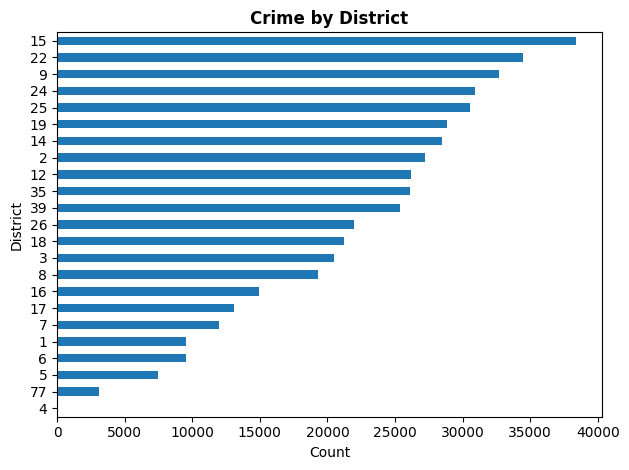

In [436]:
# District Variable Distribution pre-cleaning

df_cleaned1['dc_dist'].value_counts().sort_values(ascending = True).plot(kind = 'barh')
plt.xlabel('Count')
plt.ylabel('District')
plt.title('Crime by District', fontweight='bold')
plt.tight_layout()
plt.show()

In [437]:
# Clean Up District Variable

# Replace a specific district value: change all 6s to 9s
df_cleaned1['dc_dist'] = df_cleaned1['dc_dist'].replace(6, 9)
# https://www.nbcphiladelphia.com/news/local/philadelphia-police-to-merge-6th-and-9th-districts/3846335/#:~:text=The%20Philadelphia%20Police%20Department%20merged%20its%206th,more%20efficiently**%20*%20**Proactively%20police%20high%2Dcrime%20areas**


# Drop rows where district is 4
df_cleaned1 = df_cleaned1[df_cleaned1['dc_dist'] != 4]
# https://www.phillypolice.com/district/districts-list/

df_cleaned1['dc_dist'].value_counts()

dc_dist
9     42208
15    38374
22    34502
24    30937
25    30540
19    28830
14    28513
2     27253
12    26201
35    26116
39    25388
26    21975
18    21209
3     20495
8     19287
16    14973
17    13074
7     11983
1      9538
5      7459
77     3104
Name: count, dtype: int64

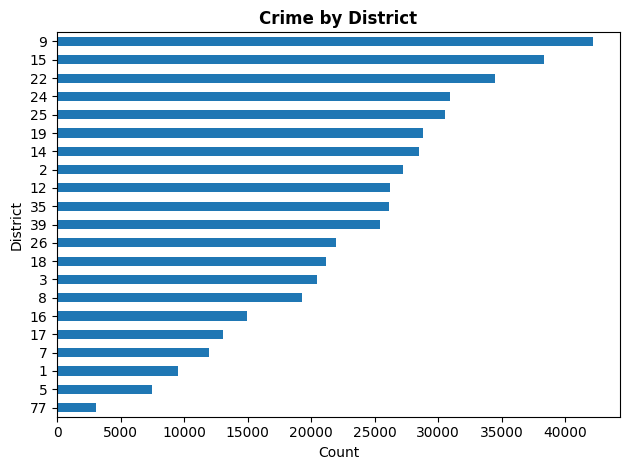

In [438]:
#DC Dist Post Cleaning Visual

df_cleaned1['dc_dist'].value_counts().sort_values(ascending = True).plot(kind = 'barh')
plt.xlabel('Count')
plt.ylabel('District')
plt.title('Crime by District', fontweight='bold')
plt.tight_layout()
plt.show()

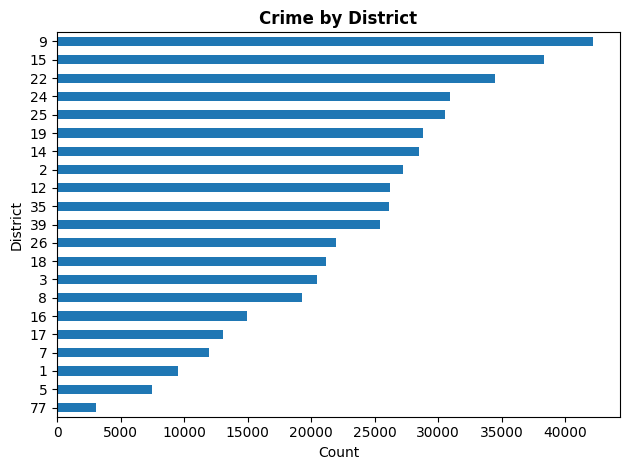

In [439]:
#ADD
#DC Dist Post Cleaning Visual
df_cleaned1['dc_dist'].value_counts().sort_values(ascending = True).plot(kind = 'barh')
plt.xlabel('Count')
plt.ylabel('District')
plt.title('Crime by District', fontweight='bold')
plt.tight_layout()
plt.show()

In [440]:
# examine data types
df_cleaned1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481959 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464629 non-null  object        
 1   cartodb_id            481959 non-null  int64         
 2   the_geom_webmercator  464512 non-null  object        
 3   objectid              481959 non-null  int64         
 4   dc_dist               481959 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481959 non-null  object        
 7   dispatch_date         481959 non-null  datetime64[ns]
 8   dispatch_time         481959 non-null  object        
 9   hour                  381340 non-null  float64       
 10  dc_key                481959 non-null  int64         
 11  location_block        481887 non-null  object        
 12  ucr_general           481959 non-null  int64         
 13  text

In [441]:
# make dispatch_date_time a date format & convert from UTC to Eastern tz b/c Philly dataset
df_cleaned1['dispatch_date_time'] = pd.to_datetime(df_cleaned1['dispatch_date_time'], utc= True)

df_cleaned1['dispatch_date_time'] = df_cleaned1['dispatch_date_time'].dt.tz_convert("America/New_York")

df_cleaned1['dispatch_date_time'] = df_cleaned1['dispatch_date_time'].dt.tz_convert("America/New_York").dt.tz_localize(None)
df_cleaned1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481959 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464629 non-null  object        
 1   cartodb_id            481959 non-null  int64         
 2   the_geom_webmercator  464512 non-null  object        
 3   objectid              481959 non-null  int64         
 4   dc_dist               481959 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481959 non-null  datetime64[ns]
 7   dispatch_date         481959 non-null  datetime64[ns]
 8   dispatch_time         481959 non-null  object        
 9   hour                  381340 non-null  float64       
 10  dc_key                481959 non-null  int64         
 11  location_block        481887 non-null  object        
 12  ucr_general           481959 non-null  int64         
 13  text

In [442]:
# create month col
df_cleaned1['month'] = df_cleaned1['dispatch_date_time'].dt.month

# create year col
df_cleaned1['year'] = df_cleaned1['dispatch_date_time'].dt.year

# create day of week col
# 0 = Mon, 1 = Tues, 2 = Wed, 3 = Thurs, 4 = Fri, 5 = Sat, 6 = Sun,  so 5 and 6 would be considered weekends
df_cleaned1['day_of_week'] = df_cleaned1['dispatch_date_time'].dt.dayofweek
df_cleaned1.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,text_general_code,point_x,point_y,lat,lng,Source,Filepath,month,year,day_of_week
0,NaN,32953,NaN,38492237,18,2,2023-06-07,2023-06-07,00:00:00,14.0,...,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2023,2
1,NaN,32954,NaN,38492238,22,4,2023-07-09,2023-07-09,00:00:00,18.0,...,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2023,6
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25,2023-04-25,00:00:00,4.0,...,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,2023,1
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19,2023-01-19,00:00:00,20.0,...,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,2023,3
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26,2023-07-26,00:00:00,19.0,...,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2023,2


In [443]:
# create weekday/weekend col
df_cleaned1['week_type'] = df_cleaned1['day_of_week'].map({
    0: "Weekday", 1: "Weekday", 2: "Weekday", 3: "Weekday", 4: "Weekday",
    5: "Weekend", 6: "Weekend"
})
df_cleaned1.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,point_x,point_y,lat,lng,Source,Filepath,month,year,day_of_week,week_type
0,NaN,32953,NaN,38492237,18,2,2023-06-07,2023-06-07,00:00:00,14.0,...,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2023,2,Weekday
1,NaN,32954,NaN,38492238,22,4,2023-07-09,2023-07-09,00:00:00,18.0,...,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2023,6,Weekend
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25,2023-04-25,00:00:00,4.0,...,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,2023,1,Weekday
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19,2023-01-19,00:00:00,20.0,...,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,2023,3,Weekday
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26,2023-07-26,00:00:00,19.0,...,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2023,2,Weekday


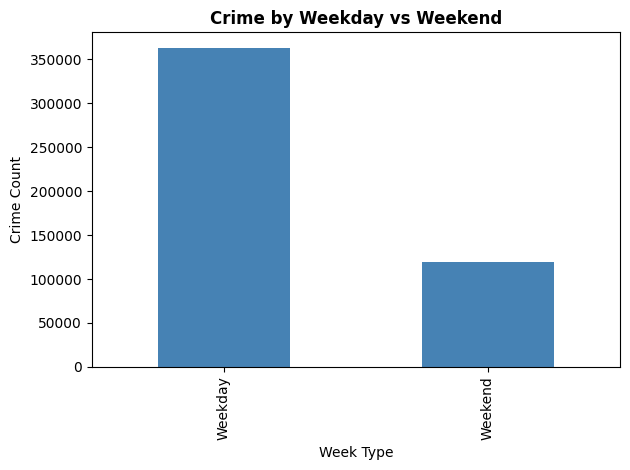

In [444]:
#Weekday vs. Weekend Distribution

df_cleaned1['week_type'].value_counts().plot(kind='bar', color='steelblue')
plt.xlabel('Week Type')
plt.ylabel('Crime Count')
plt.title('Crime by Weekday vs Weekend', fontweight='bold')
plt.tight_layout()
plt.show()

In [445]:
# create season col
df_cleaned1['season'] = df_cleaned1['month'].map({
    1: "Winter", 2: "Winter", 12: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall", 
})
df_cleaned1.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,point_y,lat,lng,Source,Filepath,month,year,day_of_week,week_type,season
0,NaN,32953,NaN,38492237,18,2,2023-06-07,2023-06-07,00:00:00,14.0,...,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2023,2,Weekday,Summer
1,NaN,32954,NaN,38492238,22,4,2023-07-09,2023-07-09,00:00:00,18.0,...,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2023,6,Weekend,Summer
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25,2023-04-25,00:00:00,4.0,...,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,2023,1,Weekday,Spring
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19,2023-01-19,00:00:00,20.0,...,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,2023,3,Weekday,Winter
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26,2023-07-26,00:00:00,19.0,...,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2023,2,Weekday,Summer


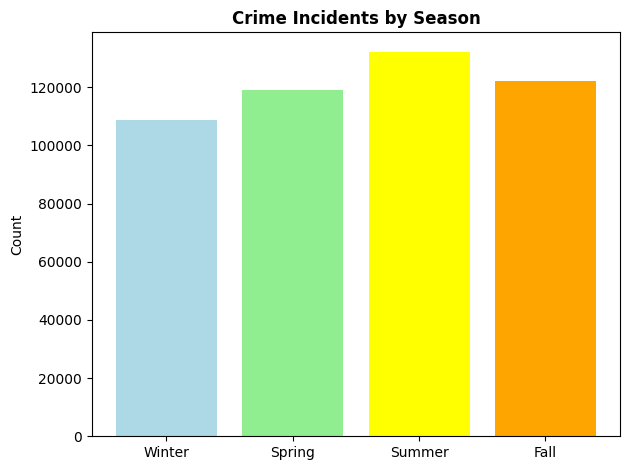

In [446]:
#Season Distribution

season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_counts = df_cleaned1['season'].value_counts().reindex(season_order)

plt.bar(season_counts.index, season_counts.values, color = ['lightblue', 'lightgreen', 'yellow','orange'])
plt.ylabel('Count')
plt.title('Crime Incidents by Season', fontweight='bold')
plt.tight_layout()
plt.show()

In [447]:
# create time of day
df_cleaned1['time_of_day'] = df_cleaned1['dispatch_date_time'].dt.hour.map(
    lambda h: 'Morning'   if 6  <= h < 12
    else      'Afternoon' if 12 <= h < 17
    else      'Evening'   if 17 <= h < 21
    else      'Night'
)

In [448]:
df_cleaned1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481959 entries, 0 to 481959
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464629 non-null  object        
 1   cartodb_id            481959 non-null  int64         
 2   the_geom_webmercator  464512 non-null  object        
 3   objectid              481959 non-null  int64         
 4   dc_dist               481959 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481959 non-null  datetime64[ns]
 7   dispatch_date         481959 non-null  datetime64[ns]
 8   dispatch_time         481959 non-null  object        
 9   hour                  381340 non-null  float64       
 10  dc_key                481959 non-null  int64         
 11  location_block        481887 non-null  object        
 12  ucr_general           481959 non-null  int64         
 13  text

In [449]:
# look at stats
df_cleaned1.describe().T

,count,mean,min,25%,50%,75%,max,std
cartodb_id,481959.0,2326640.999178,1.0,160224.5,3287769.0,3408717.5,3529207.0,1475286.121299
objectid,481959.0,18196230.236591,96.0,8569044.5,17866823.0,28010678.5,38498485.0,10895361.47807
dc_dist,481959.0,17.513973,1.0,9.0,16.0,24.0,77.0,10.993944
dispatch_date_time,481959,2024-06-21 00:49:54.985536,2022-12-31 19:05:00,2023-09-12 15:51:00,2024-06-17 16:59:00,2025-03-29 14:41:00,2025-12-31 18:58:00,NaN
dispatch_date,481959,2024-06-20 11:16:34.244738304,2022-12-31 00:00:00,2023-09-12 00:00:00,2024-06-17 00:00:00,2025-03-29 00:00:00,2025-12-31 00:00:00,NaN
hour,381340.0,13.112456,0.0,9.0,13.0,17.0,23.0,5.686816
dc_key,481959.0,203253313247.733368,197935065350.0,202324002025.5,202415054344.0,202509022354.5,202503028015001.0,412016298121.465271
ucr_general,481959.0,974.756566,100.0,600.0,700.0,1100.0,2600.0,628.356207
point_x,464527.0,1889.873908,-80.502372,-75.184119,-75.156339,-75.115242,2746280.556569,72822.087798
point_y,464527.0,223.97128,0.0,39.958716,39.993153,40.03066,301244.661214,6833.501185


In [450]:
df_cleaned1.describe(include = 'object').T

,count,unique,top,freq
the_geom,464629,231559,0101000020E6100000405E7AC148C452C00F8653499101...,704
the_geom_webmercator,464512,231527,0101000020110F00009DFF04678FE05FC150C65782A291...,704
psa,481831,6,2,156404
dispatch_time,481959,2039,00:00:00,1131
location_block,481887,63365,5500 BLOCK TULIP ST,1769
text_general_code,481959,32,Thefts,114365
Source,481959,3,2023 incidents_use.xlsx,169016
Filepath,481959,3,C:\Users\saman\Documents\DSS 740 Machine Learn...,169016
week_type,481959,2,Weekday,362698
season,481959,4,Summer,132303


In [451]:
df_cleaned1['text_general_code'].value_counts()

text_general_code
Thefts                                     114365
Other Assaults                              80021
Motor Vehicle Theft                         51747
Vandalism/Criminal Mischief                 44110
All Other Offenses                          44083
Theft from Vehicle                          33607
Fraud                                       25282
Aggravated Assault No Firearm               16152
Burglary Residential                        10384
Aggravated Assault Firearm                   8380
Weapon Violations                            8247
Narcotic / Drug Law Violations               8017
Robbery No Firearm                           7531
Robbery Firearm                              5533
Burglary Non-Residential                     4823
Receiving Stolen Property                    3929
Other Sex Offenses (Not Commercialized)      3309
DRIVING UNDER THE INFLUENCE                  2566
Arson                                        1988
Disorderly Conduct              

<Axes: ylabel='text_general_code'>

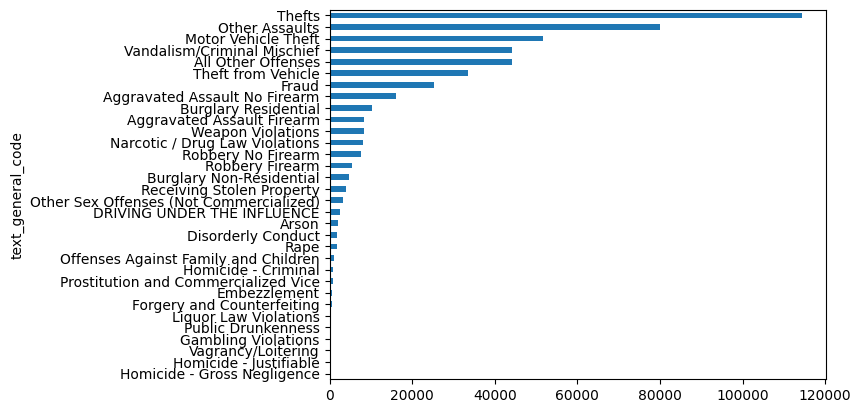

In [452]:
# look at crime type distribution
df_cleaned1['text_general_code'].value_counts().sort_values(ascending = True).plot(kind = 'barh')

array([[<Axes: title={'center': 'cartodb_id'}>,
        <Axes: title={'center': 'objectid'}>,
        <Axes: title={'center': 'dc_dist'}>,
        <Axes: title={'center': 'dispatch_date_time'}>],
       [<Axes: title={'center': 'dispatch_date'}>,
        <Axes: title={'center': 'hour'}>,
        <Axes: title={'center': 'dc_key'}>,
        <Axes: title={'center': 'ucr_general'}>],
       [<Axes: title={'center': 'point_x'}>,
        <Axes: title={'center': 'point_y'}>,
        <Axes: title={'center': 'lat'}>, <Axes: title={'center': 'lng'}>],
       [<Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'day_of_week'}>, <Axes: >]], dtype=object)

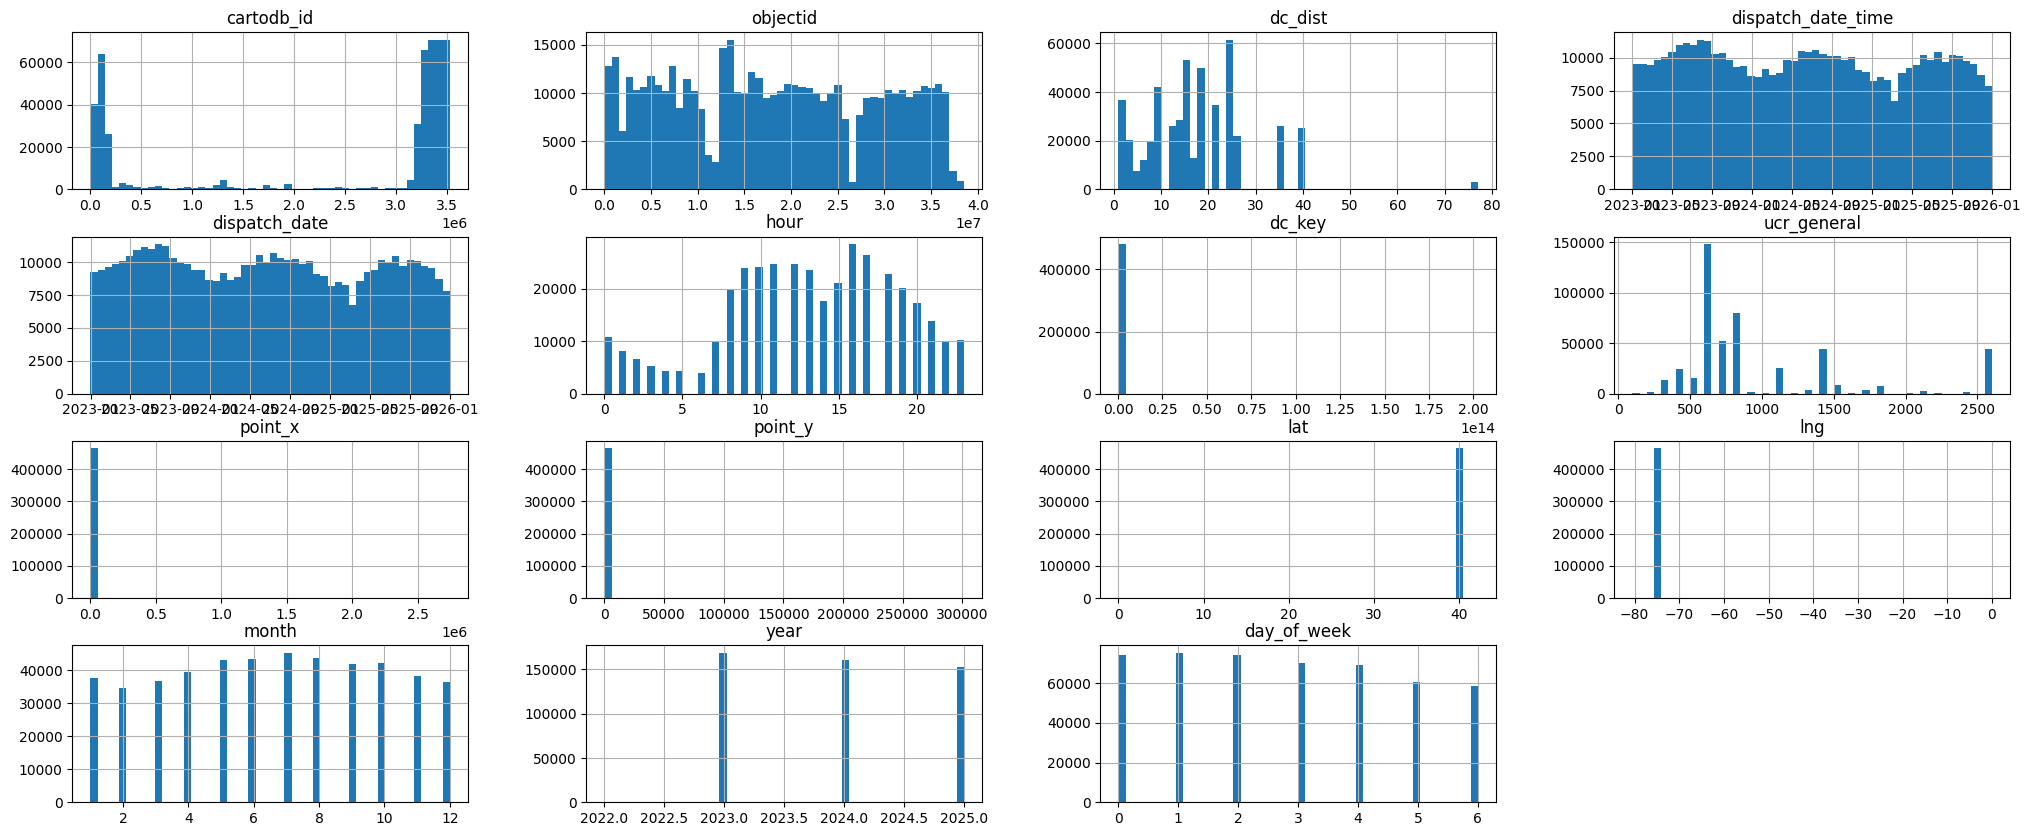

In [453]:
df_cleaned1.hist(bins = 50, figsize = (25, 10))

In [454]:
# classify crime types as violent or not and map text_general_codes
df_cleaned1['text_general_code'] = df_cleaned1['text_general_code'].str.lower().str.strip()

crime_mapping = {
    key.lower(): value for key, value in {
"Aggravated Assault Firearm":1,
"Aggravated Assault No Firearm":1,
"All Other Offenses":0,
"Arson":1,
"Burglary Non-Residential":1,
"Burglary Residential":1,
"Disorderly Conduct":0,
"DRIVING UNDER THE INFLUENCE":0,
"Embezzlement":0,
"Forgery and Counterfeiting":0,
"Fraud":0,
"Gambling Violations":0,
"Homicide - Criminal":1,
"Homicide - Gross Negligence":1,
"Homicide - Justifiable":1,
"Liquor Law Violations":0,
"Motor Vehicle Theft":0,
"Narcotic / Drug Law Violations":0,
"Offenses Against Family and Children":1,
"Other Assaults":1,
"Other Sex Offenses (Not Commercialized)":1,
"Prostitution and Commercialized Vice":0,
"Public Drunkenness":0,
"Rape":1,
"Receiving Stolen Property":0,
"Robbery Firearm":1,
"Robbery No Firearm":1,
"Theft from Vehicle":0,
"Thefts":0,
"Vagrancy/Loitering":0,
"Vandalism/Criminal Mischief":0,
"Weapon Violations":0,
}.items()}

df_cleaned1['violent_crime'] = df_cleaned1['text_general_code'].map(crime_mapping)
df_cleaned1.head()

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,lng,Source,Filepath,month,year,day_of_week,week_type,season,time_of_day,violent_crime
0,NaN,32953,NaN,38492237,18,2,2023-06-07,2023-06-07,00:00:00,14.0,...,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2023,2,Weekday,Summer,Night,1
1,NaN,32954,NaN,38492238,22,4,2023-07-09,2023-07-09,00:00:00,18.0,...,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2023,6,Weekend,Summer,Night,1
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25,2023-04-25,00:00:00,4.0,...,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,2023,1,Weekday,Spring,Night,1
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19,2023-01-19,00:00:00,20.0,...,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,2023,3,Weekday,Winter,Night,1
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26,2023-07-26,00:00:00,19.0,...,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2023,2,Weekday,Summer,Night,1


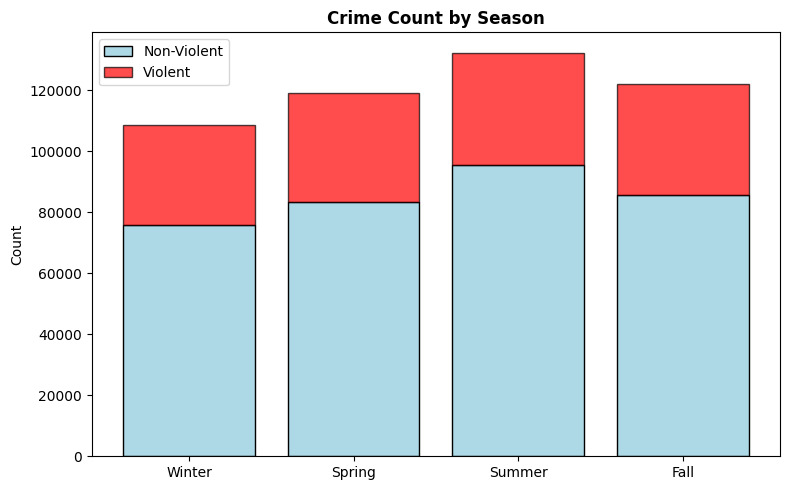

In [455]:
#Violent by Season
violent_by_season = df_cleaned1[df_cleaned1['violent_crime'] == 1]['season'].value_counts().reindex(season_order)
nonviolent_by_season = df_cleaned1[df_cleaned1['violent_crime'] == 0]['season'].value_counts().reindex(season_order)

plt.figure(figsize=(8, 5))
plt.bar(season_order, nonviolent_by_season.values, label='Non-Violent', color='lightblue', edgecolor='black')
plt.bar(season_order, violent_by_season.values, bottom=nonviolent_by_season.values, label='Violent', color='red', edgecolor='black', alpha=0.7)
plt.ylabel('Count')
plt.title('Crime Count by Season', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [456]:
df_cleaned1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481959 entries, 0 to 481959
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464629 non-null  object        
 1   cartodb_id            481959 non-null  int64         
 2   the_geom_webmercator  464512 non-null  object        
 3   objectid              481959 non-null  int64         
 4   dc_dist               481959 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481959 non-null  datetime64[ns]
 7   dispatch_date         481959 non-null  datetime64[ns]
 8   dispatch_time         481959 non-null  object        
 9   hour                  381340 non-null  float64       
 10  dc_key                481959 non-null  int64         
 11  location_block        481887 non-null  object        
 12  ucr_general           481959 non-null  int64         
 13  text

In [457]:
df_cleaned1.isnull().sum().sort_values(ascending = False)

hour                    100619
the_geom_webmercator     17447
lng                      17447
lat                      17447
point_x                  17432
point_y                  17432
the_geom                 17330
psa                        128
location_block              72
dc_dist                      0
cartodb_id                   0
dc_key                       0
dispatch_time                0
dispatch_date                0
dispatch_date_time           0
objectid                     0
ucr_general                  0
text_general_code            0
Source                       0
Filepath                     0
month                        0
year                         0
day_of_week                  0
week_type                    0
season                       0
time_of_day                  0
violent_crime                0
dtype: int64

<Axes: >

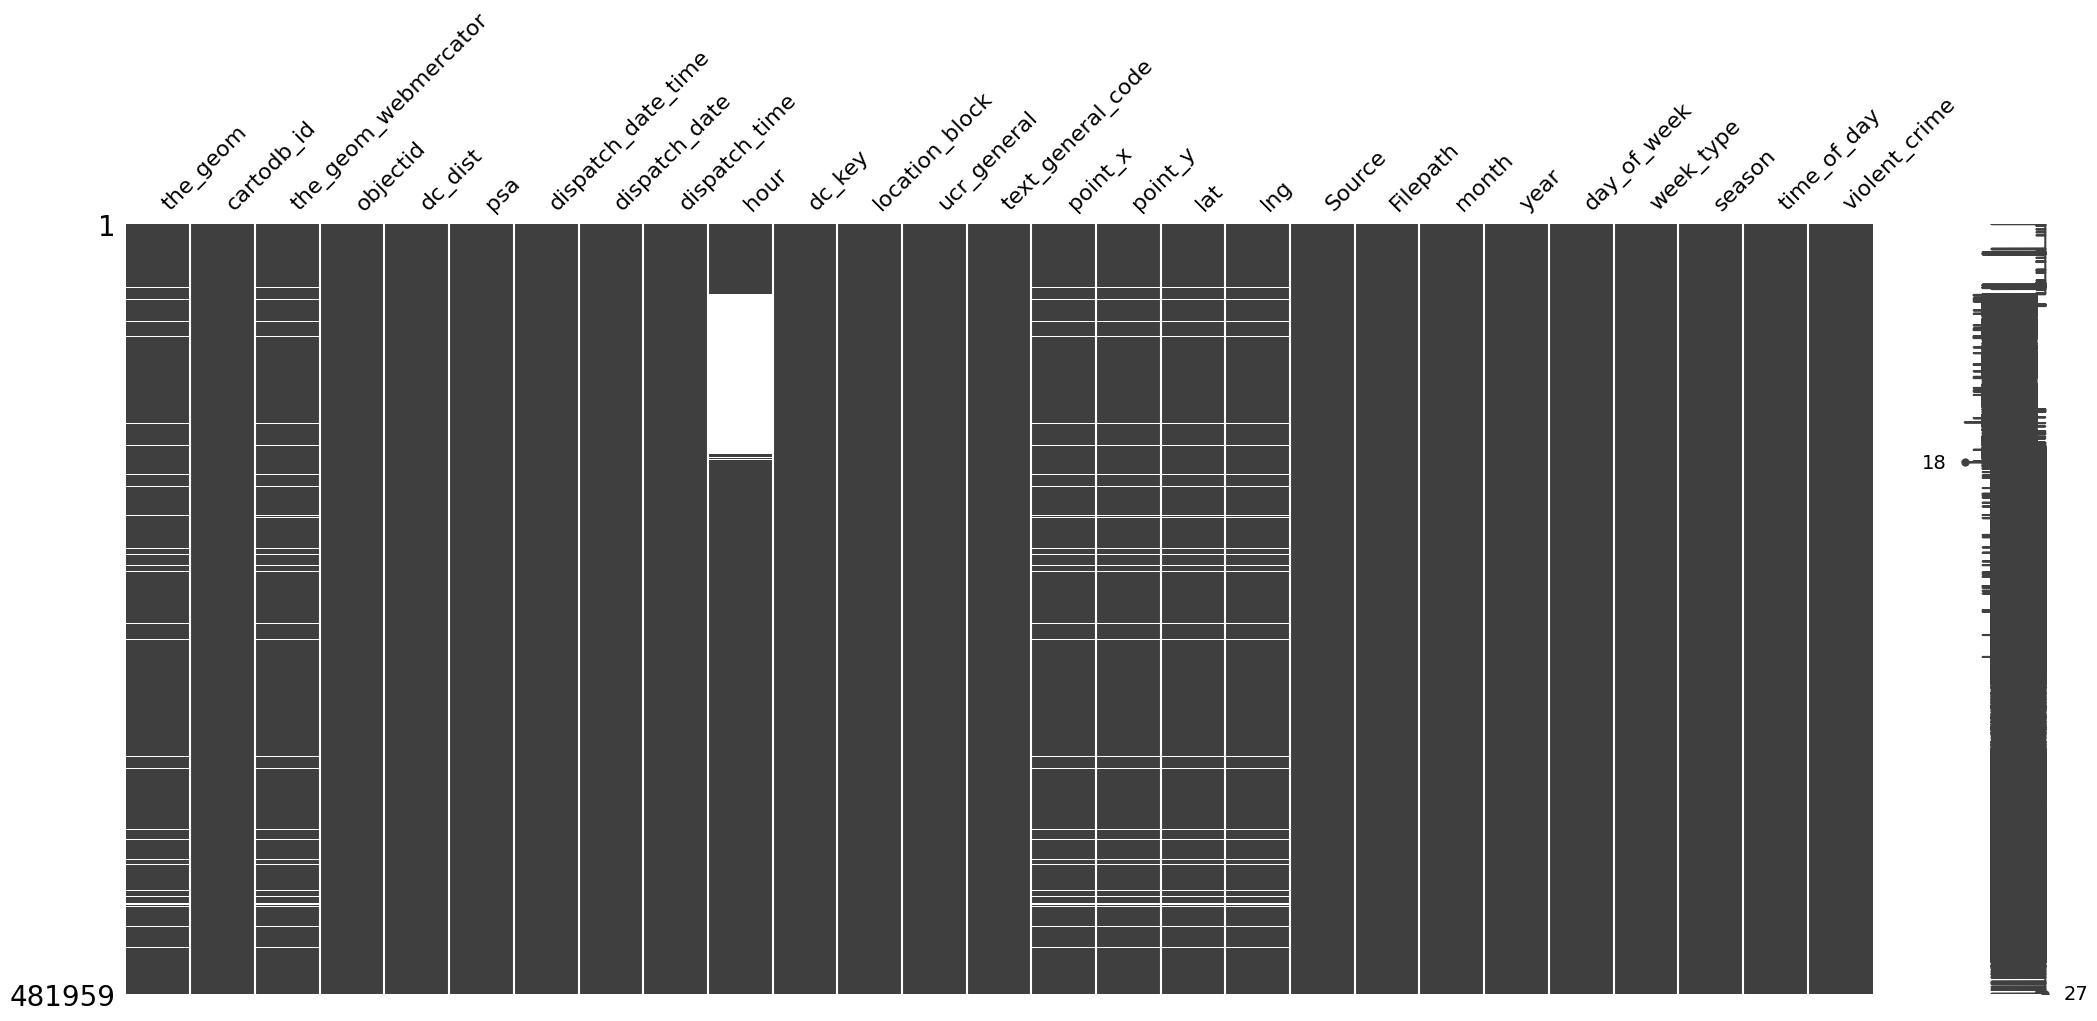

In [458]:
msno.matrix(df_cleaned1)

# Can see there is a big missing block in hour while the other missing values seem to be all associated with the same data points

In [459]:
# Drop unnecessary cols

df_cleaned1 = df_cleaned1.drop(columns=['hour','the_geom_webmercator', 'lng', 'lat', 'point_x', 'point_y', 'the_geom', 'psa', 'cartodb_id','objectid', 'dc_key', 
                      'dispatch_time', 'dispatch_date', 'Source', 'Filepath', 'location_block' ])

In [460]:
df_cleaned1.isnull().sum().sort_values(ascending = False)

dc_dist               0
dispatch_date_time    0
ucr_general           0
text_general_code     0
month                 0
year                  0
day_of_week           0
week_type             0
season                0
time_of_day           0
violent_crime         0
dtype: int64

<Axes: >

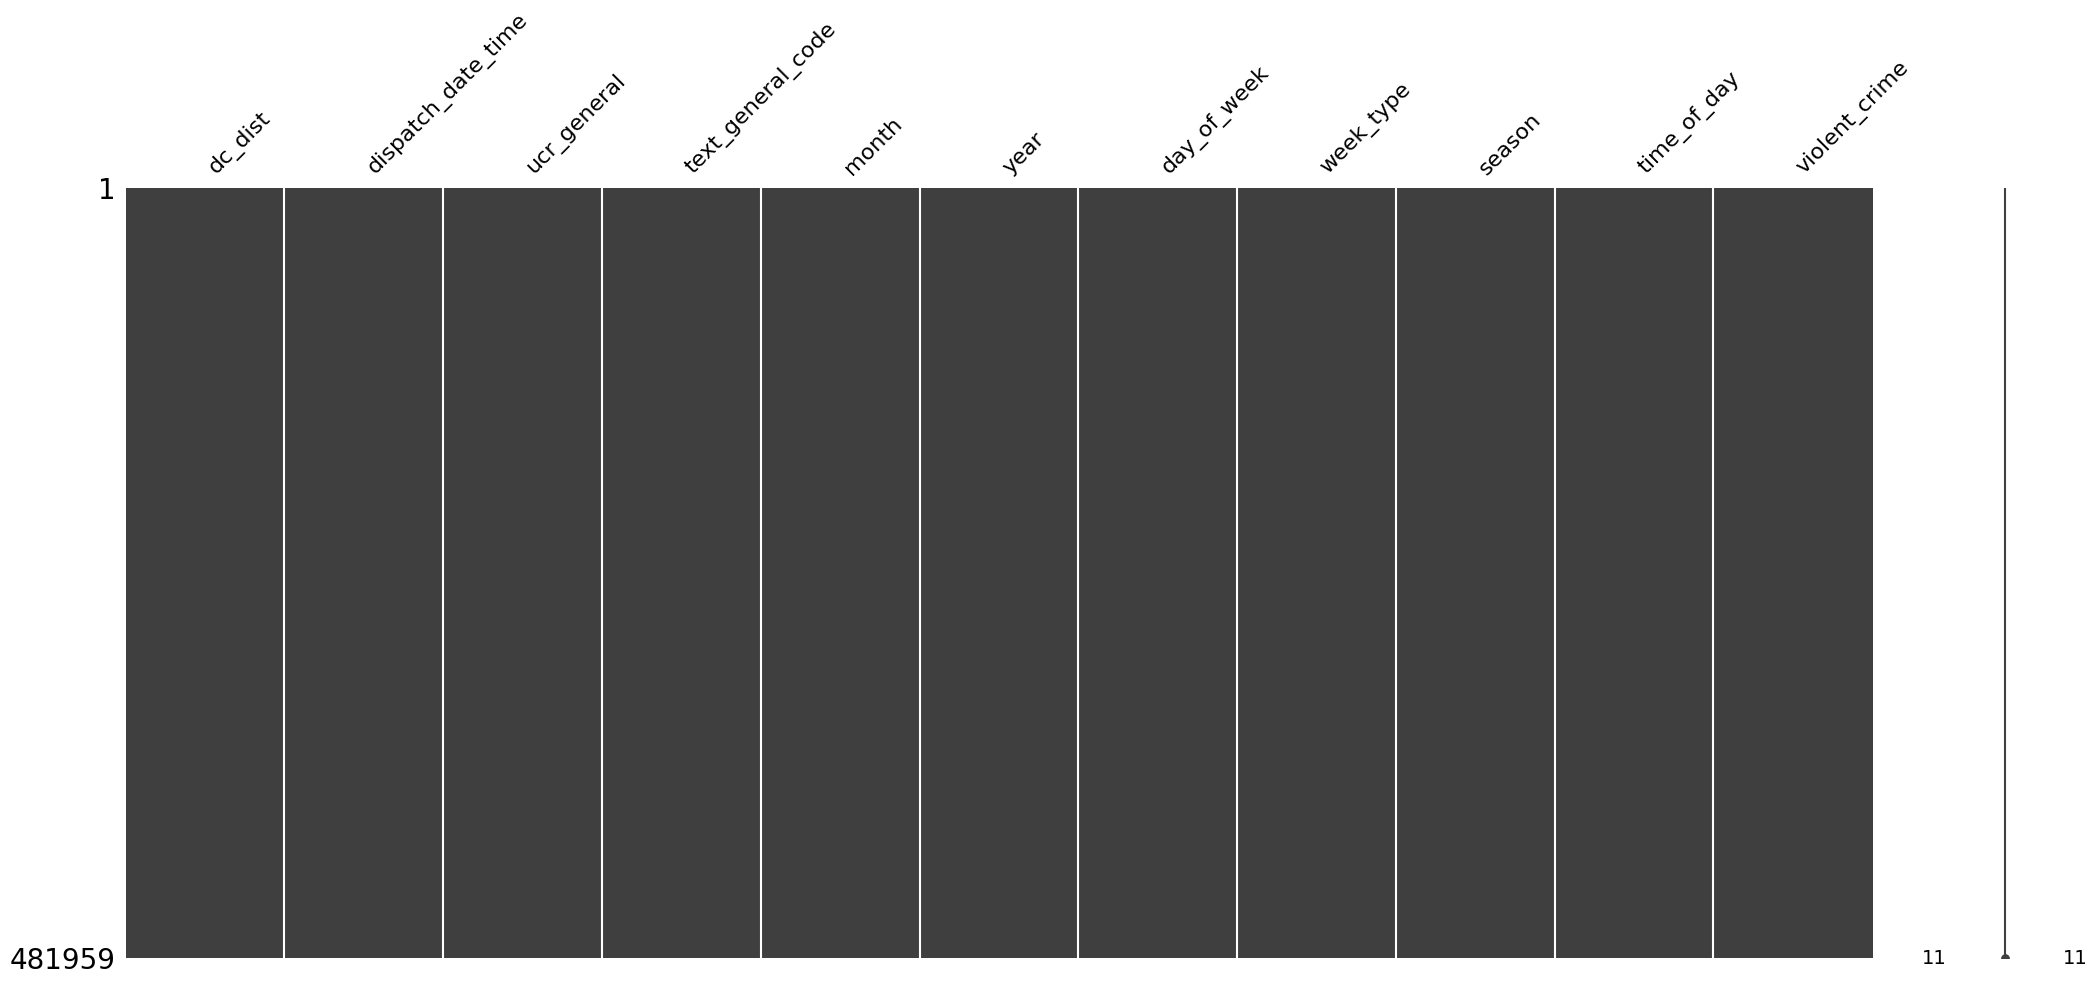

In [461]:
msno.matrix(df_cleaned1)

In [462]:
# Create New Copy / Next Step 
df2 = df_cleaned1.copy(deep = True)

In [463]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 481959 entries, 0 to 481959
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   dc_dist             481959 non-null  int64         
 1   dispatch_date_time  481959 non-null  datetime64[ns]
 2   ucr_general         481959 non-null  int64         
 3   text_general_code   481959 non-null  object        
 4   month               481959 non-null  int32         
 5   year                481959 non-null  int32         
 6   day_of_week         481959 non-null  int32         
 7   week_type           481959 non-null  object        
 8   season              481959 non-null  object        
 9   time_of_day         481959 non-null  object        
 10  violent_crime       481959 non-null  int64         
dtypes: datetime64[ns](1), int32(3), int64(3), object(4)
memory usage: 38.6+ MB


## **Aggregate Predictors and Create Response Variable for High Crime**


In [464]:
# Normalize for bias - factor in different uneven number of days (e.g., weekdays vs weekends) or uneven number of hours (e.g., evenings vs nights)

# factor for uneven days
day_counts = (
    df2.groupby(['year', 'season', 'week_type'])['dispatch_date_time']
    .apply(lambda x: x.dt.date.nunique())
    .reset_index(name='num_days')
)
 
# factor for uneven hours in a day
time_of_day_hours = {
    'Morning':   6,   # 6am–11am
    'Afternoon': 5,   # 12pm–4pm
    'Evening':   4,   # 5pm–8pm
    'Night':     9    # 9pm–5am
}

In [465]:
# Aggregate so each row is unique combination
# e.g. District 9 + Summer + Weekend + Evening + 2022 = "x" crime count
 
# Total crime count per scenario
aggregated = (
    df2.groupby(['dc_dist', 'year', 'season', 'week_type', 'time_of_day'])
    .size()
    .reset_index(name='crime_count')
)
 
# Merge in the actual day counts per year + season + week_type combo
aggregated = aggregated.merge(day_counts, on=['year', 'season', 'week_type'], how='left')
 
# Map in the number of hours per time_of_day bucket
aggregated['num_hours'] = aggregated['time_of_day'].map(time_of_day_hours)
 
# Compute crimes per day per hour — normalized fairly across all groups
aggregated['crime_rate'] = (
    aggregated['crime_count'] / aggregated['num_days'] / aggregated['num_hours']
)

In [466]:
# Original Violent crime rate - removed because data leakage (calcualting with same crimes used to build the label)
# could include previous years violent crime rate possibly in a future project
 
# Proportion of violent crimes per scenario
# (mean of 0s and 1s gives the rate, e.g. 0.4 = 40% of crimes were violent)
#violent = (
#    df2.groupby(['dc_dist', 'year', 'season', 'week_type', 'time_of_day'])['violent_crime']
#    .mean()
#    .reset_index(name='violent_crime_rate')
#)
 
# Merge violent crime rate into the aggregated dataset
#aggregated = aggregated.merge(
#    violent, on=['dc_dist', 'year', 'season', 'week_type', 'time_of_day']
#)
 
# Merge in day counts for normalization
#aggregated = aggregated.merge(week_type_day_counts, on='week_type')
#aggregated = aggregated.merge(season_day_counts, on='season')
 
# Map in the number of hours per time_of_day bucket
#aggregated['num_hours'] = aggregated['time_of_day'].map(time_of_day_hours)
 
# Compute crimes per day per hour — normalized fairly across all groups
#aggregated['crime_rate'] = (
#    aggregated['crime_count'] / aggregated['num_days_season'] / aggregated['num_days_week_type'] / aggregated['num_hours']
#)

In [467]:
# Create Response Variable (1 for High Crime, 0 for Low Crime)
# Top 25% of crime rates -> 1 (High Crime)
# Bottom 75% -> 0 (Low Crime)
 
threshold = aggregated['crime_rate'].quantile(0.75) # Top 25% of crime is high crime
 
aggregated['crime_label'] = aggregated['crime_rate'].apply(
    lambda x: 1 if x >= threshold else 0
)
 
print(f"Threshold (75th percentile crime rate): {threshold:.5f}")
print(f"High Crime rows: {aggregated['crime_label'].sum()}")
print(f"Low Crime rows:  {(aggregated['crime_label'] == 0).sum()}")

Threshold (75th percentile crime rate): 1.27160
High Crime rows: 513
Low Crime rows:  1535


In [468]:
# Created model_df2 -> Aggregated and Normalized + Response Variable Added
model_df2 = aggregated[[
    'dc_dist', 'year', 'season', 'week_type', 'time_of_day', 'crime_label'
]].copy()
 
# X = feature columns (inputs to the model)
X = model_df2[['dc_dist', 'year', 'season', 'week_type', 'time_of_day']]
 
# y = response variable (what the model learns to predict)
y = model_df2['crime_label']
 
print("\nFinal dataset sample:")
print(model_df2.head(15))


Final dataset sample:
    dc_dist  year  season week_type time_of_day  crime_label
0         1  2022  Winter   Weekend       Night            0
1         1  2023    Fall   Weekday   Afternoon            0
2         1  2023    Fall   Weekday     Evening            0
3         1  2023    Fall   Weekday     Morning            0
4         1  2023    Fall   Weekday       Night            0
5         1  2023    Fall   Weekend   Afternoon            0
6         1  2023    Fall   Weekend     Evening            0
7         1  2023    Fall   Weekend     Morning            0
8         1  2023    Fall   Weekend       Night            0
9         1  2023  Spring   Weekday   Afternoon            0
10        1  2023  Spring   Weekday     Evening            0
11        1  2023  Spring   Weekday     Morning            0
12        1  2023  Spring   Weekday       Night            0
13        1  2023  Spring   Weekend   Afternoon            0
14        1  2023  Spring   Weekend     Evening            0


In [469]:
model_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2048 entries, 0 to 2047
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   dc_dist      2048 non-null   int64 
 1   year         2048 non-null   int32 
 2   season       2048 non-null   object
 3   week_type    2048 non-null   object
 4   time_of_day  2048 non-null   object
 5   crime_label  2048 non-null   int64 
dtypes: int32(1), int64(2), object(3)
memory usage: 88.1+ KB


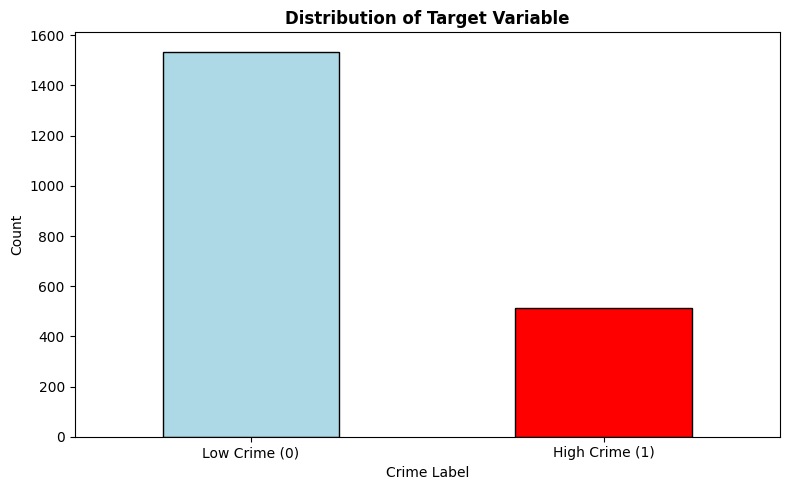

In [470]:
# Distribution of Crime

plt.figure(figsize=(8, 5))
model_df2['crime_label'].value_counts().plot(kind='bar', color=['lightblue', 'red'], edgecolor='black')
plt.xlabel('Crime Label')
plt.ylabel('Count')
plt.title('Distribution of Target Variable', fontweight='bold')
plt.xticks(ticks=[0,1], labels=['Low Crime (0)', 'High Crime (1)'], rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

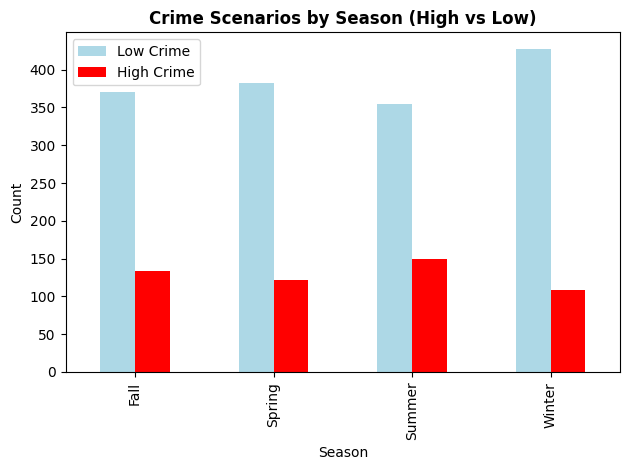

In [471]:
# Crime by Season

plt.figure(figsize=(10, 5))
model_df2.groupby('season')['crime_label'].value_counts().unstack().plot(kind='bar', color=['lightblue', 'red'])
plt.xlabel('Season')
plt.ylabel('Count')
plt.title('Crime Scenarios by Season (High vs Low)', fontweight='bold')
plt.legend(['Low Crime', 'High Crime'])
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

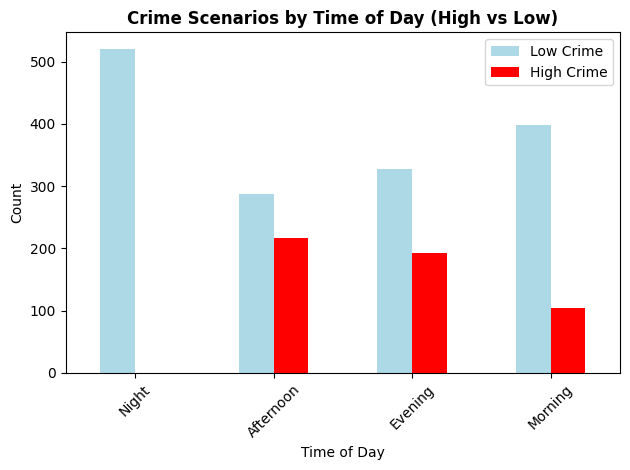

In [472]:
# Crime by Time of Day

# Really interesting that night doesn't have high crime but night does have a lot of hours, midnight to 6 AM probably not much if any crime.
# In future study, might consider splitting night into 2, early night (9pm-midnight) and late night (midnight to 6 am)

time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
plt.figure(figsize=(10, 5))
model_df2['time_of_day'] = pd.Categorical(model_df2['time_of_day'], categories=time_order, ordered=True)
model_df2.groupby('time_of_day', sort=False, observed=True)['crime_label'].value_counts().unstack().plot(kind='bar', color=['lightblue', 'red'])
plt.xlabel('Time of Day')
plt.ylabel('Count')
plt.title('Crime Scenarios by Time of Day (High vs Low)', fontweight='bold')
plt.legend(['Low Crime', 'High Crime'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1600x1000 with 0 Axes>

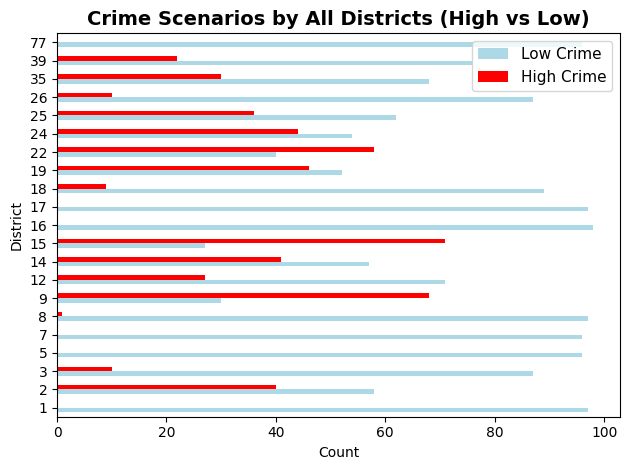

In [473]:
# Crime Scenarios by district

plt.figure(figsize=(16, 10))
model_df2.groupby('dc_dist')['crime_label'].value_counts().unstack().plot(kind='barh', color=['lightblue', 'red'])
plt.xlabel('Count')
plt.ylabel('District')
plt.title('Crime Scenarios by All Districts (High vs Low)', fontweight='bold', fontsize=14)
plt.legend(['Low Crime', 'High Crime'], fontsize=11)
plt.tight_layout()
plt.show()

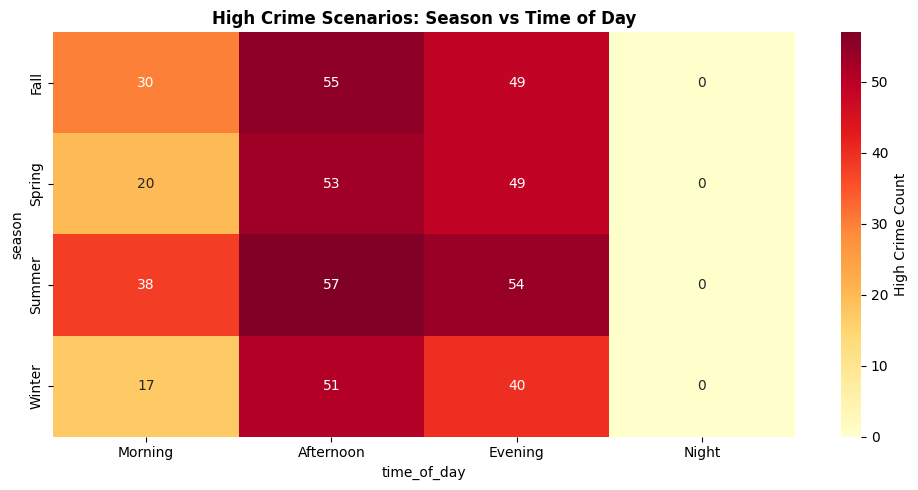

In [474]:
#Heatmap: Season vs. Time of Day 

pivot = pd.crosstab(model_df2['season'], model_df2['time_of_day'], model_df2['crime_label'], aggfunc='sum')

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'High Crime Count'})
plt.title('High Crime Scenarios: Season vs Time of Day', fontweight='bold')
plt.tight_layout()
plt.show()

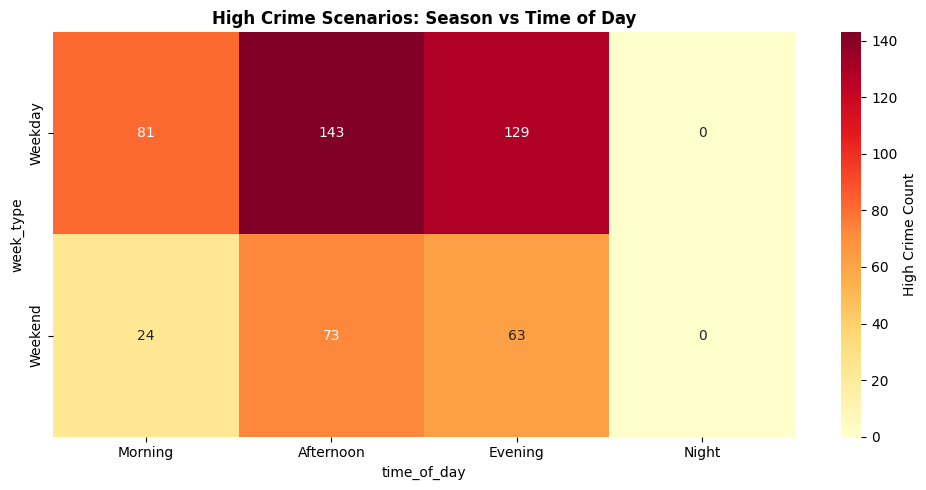

In [475]:
# Heatmap: Week Day Type vs. Day of Week

pivot = pd.crosstab(model_df2['week_type'], model_df2['time_of_day'], model_df2['crime_label'], aggfunc='sum')

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'High Crime Count'})
plt.title('High Crime Scenarios: Season vs Time of Day', fontweight='bold')
plt.tight_layout()
plt.show()

# **Model Creation & Training: Logistic Regression, Decision Tree, and XGBoost**

In [476]:
# 1. Create dummy variables (0/1)
model_df3 = pd.get_dummies(
    model_df2,
    columns=['dc_dist', 'year', 'season', 'week_type', 'time_of_day'],
    drop_first=True,
    dtype=int
)

# 2. Define X and y
X = model_df3.drop(columns=['crime_label'])
y = model_df3['crime_label']

# 3. Train/Test Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3.5 Scale Data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)   # no fit_ to avoid data leakage

In [477]:
model_df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2048 entries, 0 to 2047
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   crime_label            2048 non-null   int64
 1   dc_dist_2              2048 non-null   int64
 2   dc_dist_3              2048 non-null   int64
 3   dc_dist_5              2048 non-null   int64
 4   dc_dist_7              2048 non-null   int64
 5   dc_dist_8              2048 non-null   int64
 6   dc_dist_9              2048 non-null   int64
 7   dc_dist_12             2048 non-null   int64
 8   dc_dist_14             2048 non-null   int64
 9   dc_dist_15             2048 non-null   int64
 10  dc_dist_16             2048 non-null   int64
 11  dc_dist_17             2048 non-null   int64
 12  dc_dist_18             2048 non-null   int64
 13  dc_dist_19             2048 non-null   int64
 14  dc_dist_22             2048 non-null   int64
 15  dc_dist_24             2048 non-null  

## **1. Logistic Regression Models**

In [478]:
# Logistic Regression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# 6. Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nLogistic Regression Coefficients:")
print(coef_df)

Accuracy: 0.9138
Precision: 0.7701
Recall: 0.9351
F1 Score: 0.8446
AUC: 0.9815

Confusion Matrix:
[[418  43]
 [ 10 144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       461
           1       0.77      0.94      0.84       154

    accuracy                           0.91       615
   macro avg       0.87      0.92      0.89       615
weighted avg       0.92      0.91      0.92       615


Logistic Regression Coefficients:
                  Feature  Coefficient
29      time_of_day_Night    -3.444518
8              dc_dist_15     2.095070
5               dc_dist_9     2.075292
26      week_type_Weekend    -1.616563
13             dc_dist_22     1.536709
27  time_of_day_Afternoon     1.311646
12             dc_dist_19     1.307623
14             dc_dist_24     1.293437
20              year_2023     1.140057
15             dc_dist_25     1.095730
7              dc_dist_14     1.095231
0               dc_dist_2

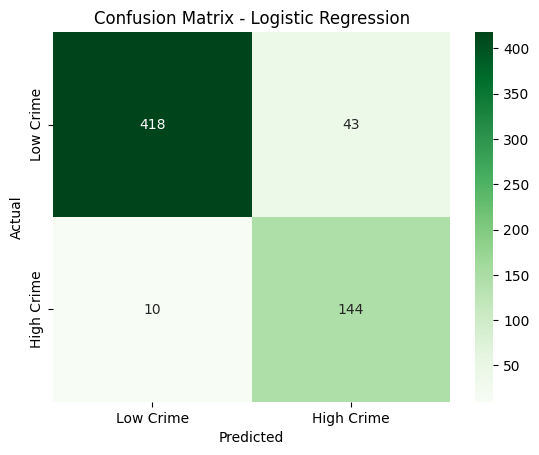

In [479]:
# Logistic Regression
y_pred = log_model.predict(X_test_scaled)

cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low Crime', 'High Crime'], yticklabels=['Low Crime', 'High Crime'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [480]:
# Below is the tuned logistic regression model. 
# The output metrics are slightly better
# Accuracy, precision, recall f1 are all slighly better. not by much

# 4. Hyperparameter Grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],              # regularization strength
    'penalty': ['l1', 'l2'],                  # Lasso vs Ridge
    'solver': ['liblinear'],                  # supports both l1 and l2
    'class_weight': [None, 'balanced']
}

# 5. Grid Search - Cross validation with 5 folds, train on 4 folds, validate on 1
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_log = grid.best_estimator_

print("Best Parameters:", grid.best_params_)


y_pred = best_log.predict(X_test_scaled)
y_prob = best_log.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_log.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df)

Best Parameters: {'C': 10, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.9398
Precision: 0.898
Recall: 0.8571
F1 Score: 0.8771
AUC: 0.982

Confusion Matrix:
[[446  15]
 [ 22 132]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       461
           1       0.90      0.86      0.88       154

    accuracy                           0.94       615
   macro avg       0.93      0.91      0.92       615
weighted avg       0.94      0.94      0.94       615

                  Feature  Coefficient
29      time_of_day_Night    -5.210271
8              dc_dist_15     3.013604
5               dc_dist_9     2.927176
20              year_2023     2.782482
21              year_2024     2.357053
13             dc_dist_22     2.190923
26      week_type_Weekend    -1.959976
12             dc_dist_19     1.928172
22              year_2025     1.906012
14             dc_dist_24     1.815101
15          

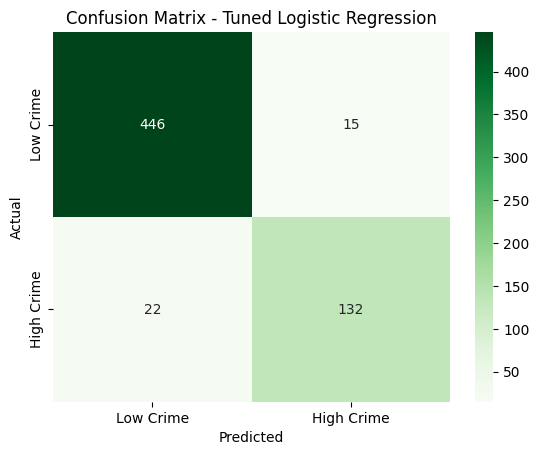

In [481]:
# Tuned Logistic Regression
y_pred = best_log.predict(X_test_scaled)

cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low Crime', 'High Crime'], yticklabels=['Low Crime', 'High Crime'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.show()

## **2. Decision Tree Models**

In [482]:
# Decision Tree - the output metrics are much better in this model

# 4. Fit Decision Tree
tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

tree_model.fit(X_train_scaled, y_train) # Could just use x_train too for decision tree and XGBoost, but will keep scaled to keep consistent

# 5. Predictions
y_pred = tree_model.predict(X_test_scaled)
y_prob = tree_model.predict_proba(X_test_scaled)[:, 1]

# 6. Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nDecision Tree Feature Importances:")
print(importance_df)

Accuracy: 0.878
Precision: 0.7883
Recall: 0.7013
F1 Score: 0.7423
AUC: 0.8192

Confusion Matrix:
[[432  29]
 [ 46 108]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       461
           1       0.79      0.70      0.74       154

    accuracy                           0.88       615
   macro avg       0.85      0.82      0.83       615
weighted avg       0.87      0.88      0.88       615


Decision Tree Feature Importances:
                  Feature  Importance
29      time_of_day_Night    0.195326
26      week_type_Weekend    0.066303
5               dc_dist_9    0.057944
13             dc_dist_22    0.049112
28    time_of_day_Evening    0.049047
8              dc_dist_15    0.047636
27  time_of_day_Afternoon    0.035681
25          season_Winter    0.034275
12             dc_dist_19    0.031955
14             dc_dist_24    0.030709
2               dc_dist_5    0.028773
3               dc_dist_7    0.028334

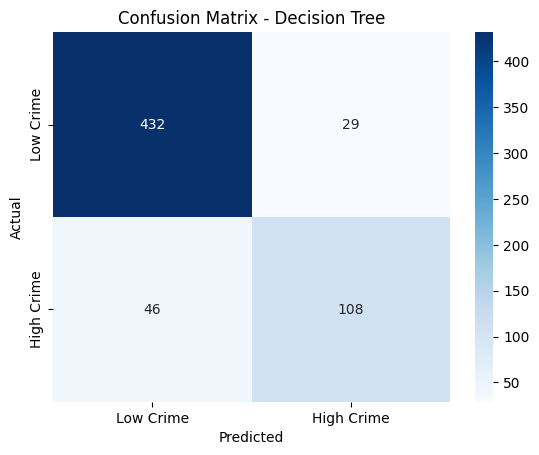

In [483]:
# Decision Tree
y_pred = tree_model.predict(X_test_scaled)

cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Crime', 'High Crime'], yticklabels=['Low Crime', 'High Crime'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

In [484]:
# Tuned Decision Tree - 

# 4. Set up hyperparameter grid 
#  The model look at various specifications, for example: max depth, looks at
# max depth of 3, 5, 7, 10, and no max
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

# 5. Run grid search
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

# Best tuned model
best_tree = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# 6. Predictions
y_pred = best_tree.predict(X_test_scaled)
y_prob = best_tree.predict_proba(X_test_scaled)[:, 1]

# 7. Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 8. Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTuned Decision Tree Feature Importances:")
print(importance_df)

Best Parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Accuracy: 0.9073
Precision: 0.787
Recall: 0.8636
F1 Score: 0.8235
AUC: 0.9101

Confusion Matrix:
[[425  36]
 [ 21 133]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       461
           1       0.79      0.86      0.82       154

    accuracy                           0.91       615
   macro avg       0.87      0.89      0.88       615
weighted avg       0.91      0.91      0.91       615


Tuned Decision Tree Feature Importances:
                  Feature  Importance
29      time_of_day_Night    0.207645
26      week_type_Weekend    0.055659
5               dc_dist_9    0.055556
13             dc_dist_22    0.052940
8              dc_dist_15    0.049721
28    time_of_day_Evening    0.039729
27  time_of_day_Afternoon    0.038229
21              year_2024    0.032566
7        

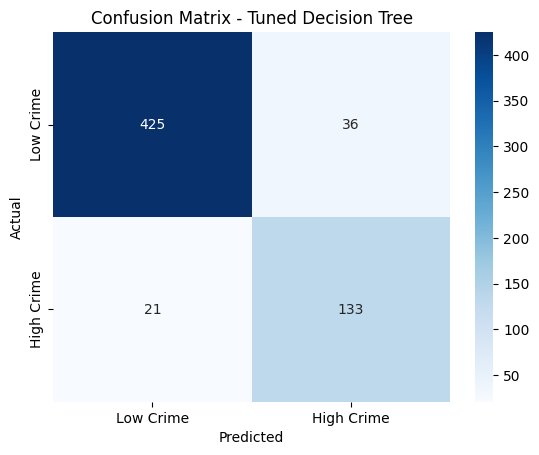

In [485]:
# Tuned Decision Tree
y_pred = best_tree.predict(X_test_scaled)

cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Crime', 'High Crime'], yticklabels=['Low Crime', 'High Crime'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Decision Tree')
plt.show()

## **3. XGBoost Models**

Results may **slightly** vary between computers, but we tried to minimize with using nthread=1. Picked one computer to use for results.

In [486]:
from xgboost import XGBClassifier

# XGBoost - you might need to intall xgboost
# in your terminal type "pip install xgboost" without the quotation marks


# 4. Fit XGBoost
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    nthread=1,        # single thread = identical results for all team
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# 6. Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nXGBoost Feature Importances:")
print(importance_df)

Accuracy: 0.935
Precision: 0.9318
Recall: 0.7987
F1 Score: 0.8601
AUC: 0.9806

Confusion Matrix:
[[452   9]
 [ 31 123]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       461
           1       0.93      0.80      0.86       154

    accuracy                           0.93       615
   macro avg       0.93      0.89      0.91       615
weighted avg       0.93      0.93      0.93       615


XGBoost Feature Importances:
                  Feature  Importance
29      time_of_day_Night    0.157699
5               dc_dist_9    0.066741
8              dc_dist_15    0.061881
26      week_type_Weekend    0.049170
13             dc_dist_22    0.044928
2               dc_dist_5    0.043158
10             dc_dist_17    0.042461
3               dc_dist_7    0.038385
4               dc_dist_8    0.036930
19             dc_dist_77    0.036707
15             dc_dist_25    0.034136
9              dc_dist_16    0.033927
12   

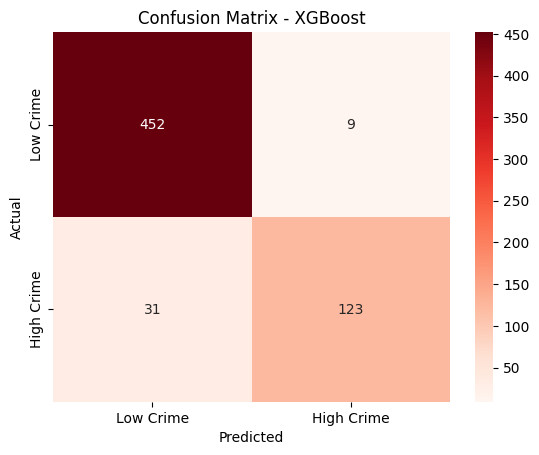

In [487]:
# XGBoost
y_pred = xgb_model.predict(X_test_scaled)

cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Low Crime', 'High Crime'], yticklabels=['Low Crime', 'High Crime'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [488]:
# Tuned XGBoost

# 4. Handle class imbalance (VERY important)
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# 5. Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, scale_pos_weight]
}

# 6. Grid Search
grid = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        nthread=1,
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

# Best model
best_xgb = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# 7. Predictions
y_pred = best_xgb.predict(X_test_scaled)
y_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]

# 8. Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 9. Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTuned XGBoost Feature Importances:")
print(importance_df)

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 0.8}
Accuracy: 0.948
Precision: 0.891
Recall: 0.9026
F1 Score: 0.8968
AUC: 0.9826

Confusion Matrix:
[[444  17]
 [ 15 139]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       461
           1       0.89      0.90      0.90       154

    accuracy                           0.95       615
   macro avg       0.93      0.93      0.93       615
weighted avg       0.95      0.95      0.95       615


Tuned XGBoost Feature Importances:
                  Feature  Importance
29      time_of_day_Night    0.183284
8              dc_dist_15    0.063433
2               dc_dist_5    0.058667
19             dc_dist_77    0.054473
3               dc_dist_7    0.054140
10             dc_dist_17    0.053476
5               dc_dist_9    0.053035
4               dc_dist_8    0.050649
9        

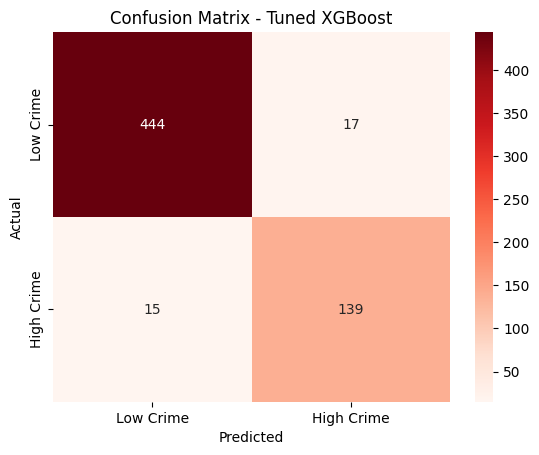

In [489]:
# XGBoost
y_pred = best_xgb.predict(X_test_scaled)

cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Low Crime', 'High Crime'], yticklabels=['Low Crime', 'High Crime'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.show()

## **Model Evaluations & Comparisons**

In [490]:
# ROC Curve for the best models after hyperparameter tuning

POS = 1  # the positive class in your y
models = {
    "Logistic Regression": log_model,
    "Tuned Logistic Regression": best_log,
    "Decision Tree": tree_model,
    "Tuned Decision Tree": best_tree,
    "XGBoost": xgb_model,
    "Tuned XGBoost": best_xgb
}

In [491]:
def positive_scores(clf, X, pos_label=POS):
    """
    Return scores for the positive class (pos_label).
    Uses predict_proba if available; otherwise decision_function.
    Ensures scores increase with P(pos_label).
    """
    # predict_proba → pick the correct column by class name
    if hasattr(clf, "predict_proba"):
        cls = clf.classes_
        j = int(np.where(cls == pos_label)[0][0])  # index of positive class
        return clf.predict_proba(X)[:, j]

    # decision_function → ensure sign matches pos_label
    if hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        # If classes_ exist and classes_[1] != pos_label, flip the sign
        if hasattr(clf, "classes_") and clf.classes_.shape[0] == 2:
            if clf.classes_[1] != pos_label:
                s = -s
        return s

    raise ValueError("Classifier must implement predict_proba or decision_function.")

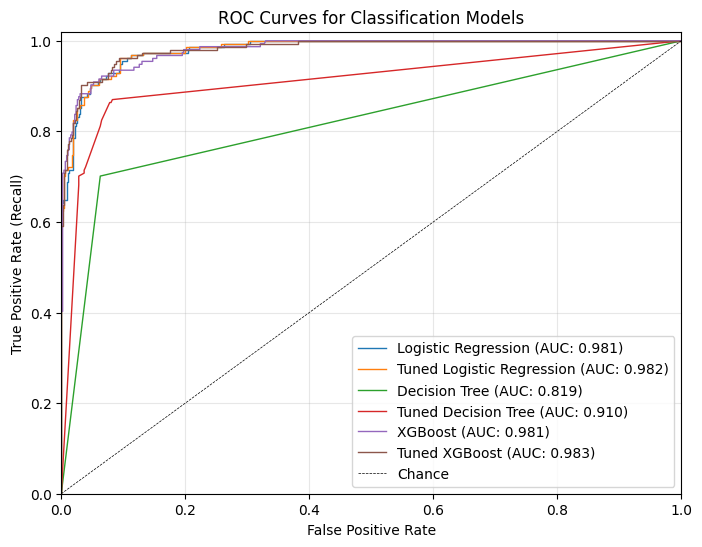

In [492]:
plt.figure(figsize=(8,6))
for name, clf in models.items():
    scores = positive_scores(clf, X_test_scaled, POS)
    fpr, tpr, _ = roc_curve(y_test, scores, pos_label=POS)
    roc_auc = auc(fpr, tpr)                   # same as roc_auc_score(y_test, scores, labels=[...])
    plt.plot(fpr, tpr, lw=1, label=f"{name} (AUC: {roc_auc:.3f})")

# Chance line
plt.plot([0,1], [0,1], 'k--', lw=0.5, label="Chance")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves for Classification Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [493]:
# AUC Score, F1 Score, and Recall all important (accuracy could be missleading because of class imbalance)

results_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Tuned Logistic Regression',
        'Decision Tree',
        'Tuned Decision Tree',
        'XGBoost',
        'Tuned XGBoost'
    ],
    'Accuracy': [0.9122, 0.9398, 0.8911, 0.922, 0.9398, 0.922],
    'Precision': [0.766, 0.898, 0.7919, 0.863, 0.9398, 0.788],
    'Recall': [0.9351, 0.8571, 0.7662, 0.8182, 0.8117, 0.9416],
    'F1 Score': [0.8421, 0.8771, 0.7789, 0.84, 0.8711, 0.858],
    'AUC': [0.9816, 0.9819, 0.8495, 0.9322, 0.9819, 0.9847]
})

# Sort by best model (F1 Score)
results_df = results_df.sort_values(by='F1 Score', ascending=False)

print(results_df)

                       Model  Accuracy  Precision  Recall  F1 Score     AUC
1  Tuned Logistic Regression    0.9398     0.8980  0.8571    0.8771  0.9819
4                    XGBoost    0.9398     0.9398  0.8117    0.8711  0.9819
5              Tuned XGBoost    0.9220     0.7880  0.9416    0.8580  0.9847
0        Logistic Regression    0.9122     0.7660  0.9351    0.8421  0.9816
3        Tuned Decision Tree    0.9220     0.8630  0.8182    0.8400  0.9322
2              Decision Tree    0.8911     0.7919  0.7662    0.7789  0.8495


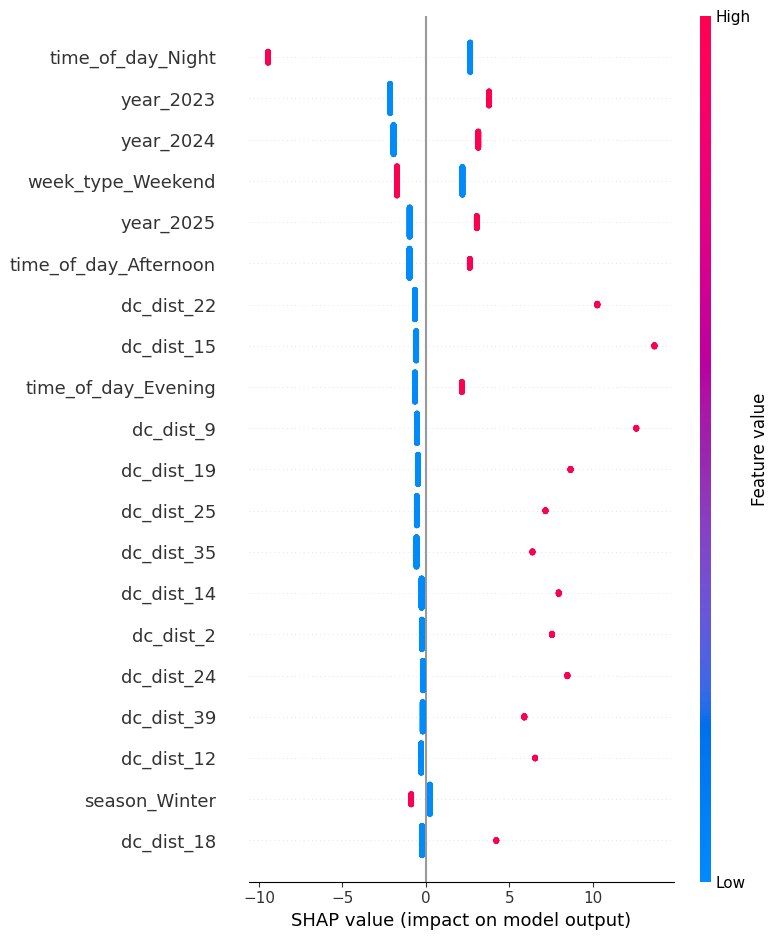

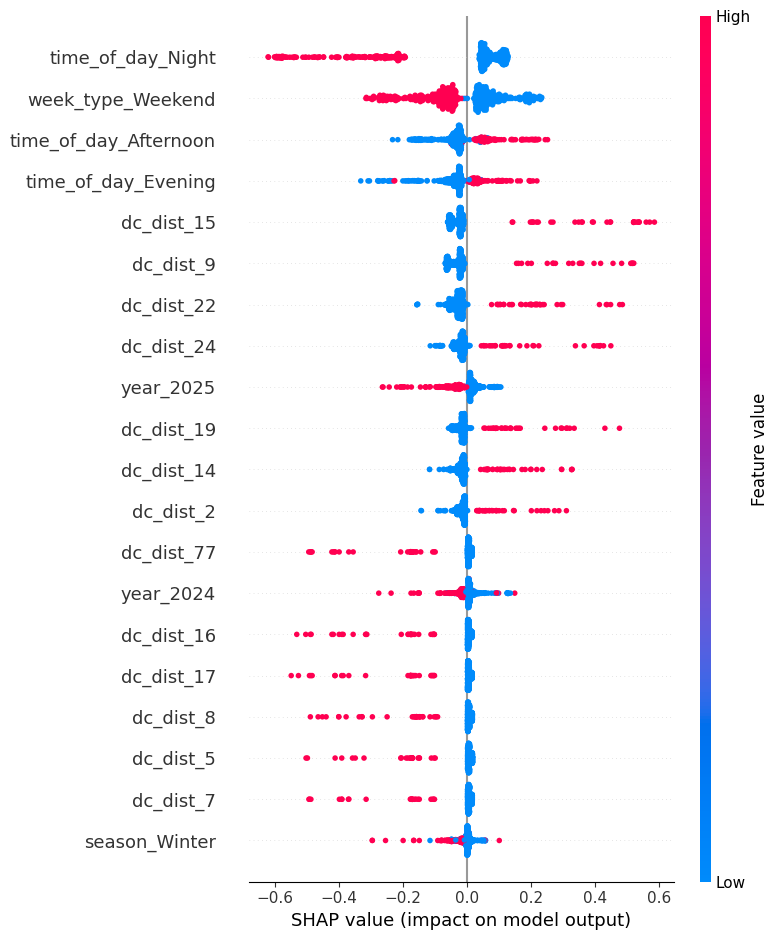

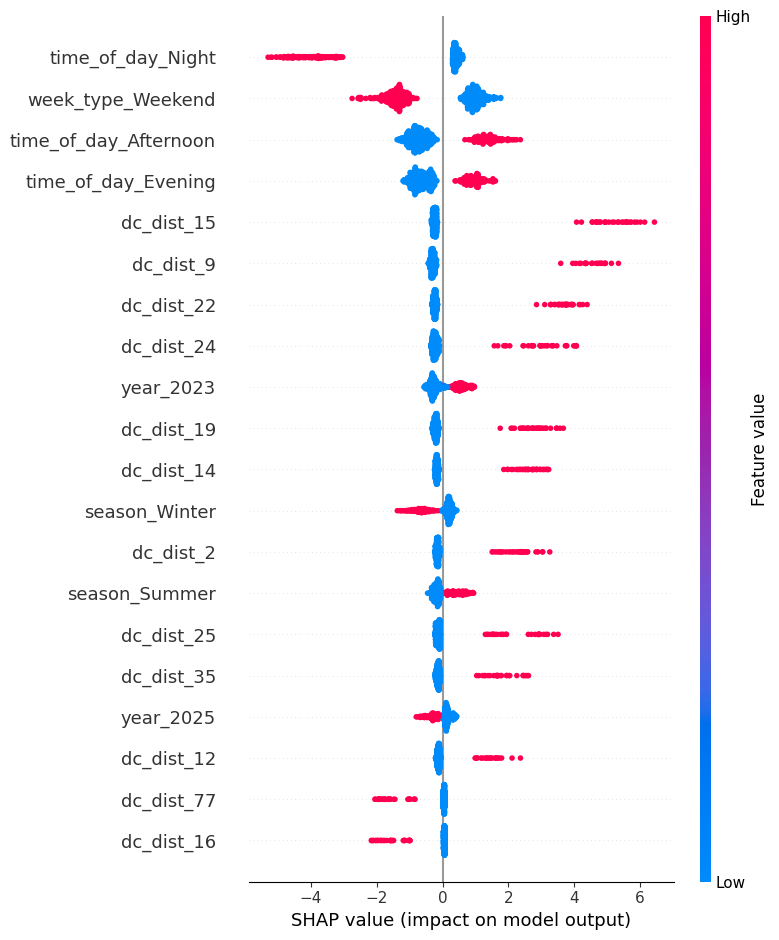

In [494]:
# SHAP Test 

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Logistic Regression
explainer_lr = LinearExplainer(best_log, X_train_scaled_df)
shap_values_lr = explainer_lr.shap_values(X_test_scaled_df)
shap.summary_plot(shap_values_lr, X_test_scaled_df)

# Decision Tree
explainer_dt = TreeExplainer(best_tree)
shap_values_dt = explainer_dt.shap_values(X_test_scaled_df)
shap.summary_plot(shap_values_dt[:, :, 1], X_test_scaled_df)

# XGBoost
explainer_xgb = TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test_scaled_df)
shap.summary_plot(shap_values_xgb, X_test_scaled_df)
